<a href="https://colab.research.google.com/github/nicole205dev/Data-Wrangling/blob/main/Airplane_Crashes_Data_Cleaning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Upload the dataset
from google.colab import files

uploaded = files.upload()

Saving Airplane_Crashes_and_Fatalities_Since_1908.csv to Airplane_Crashes_and_Fatalities_Since_1908.csv


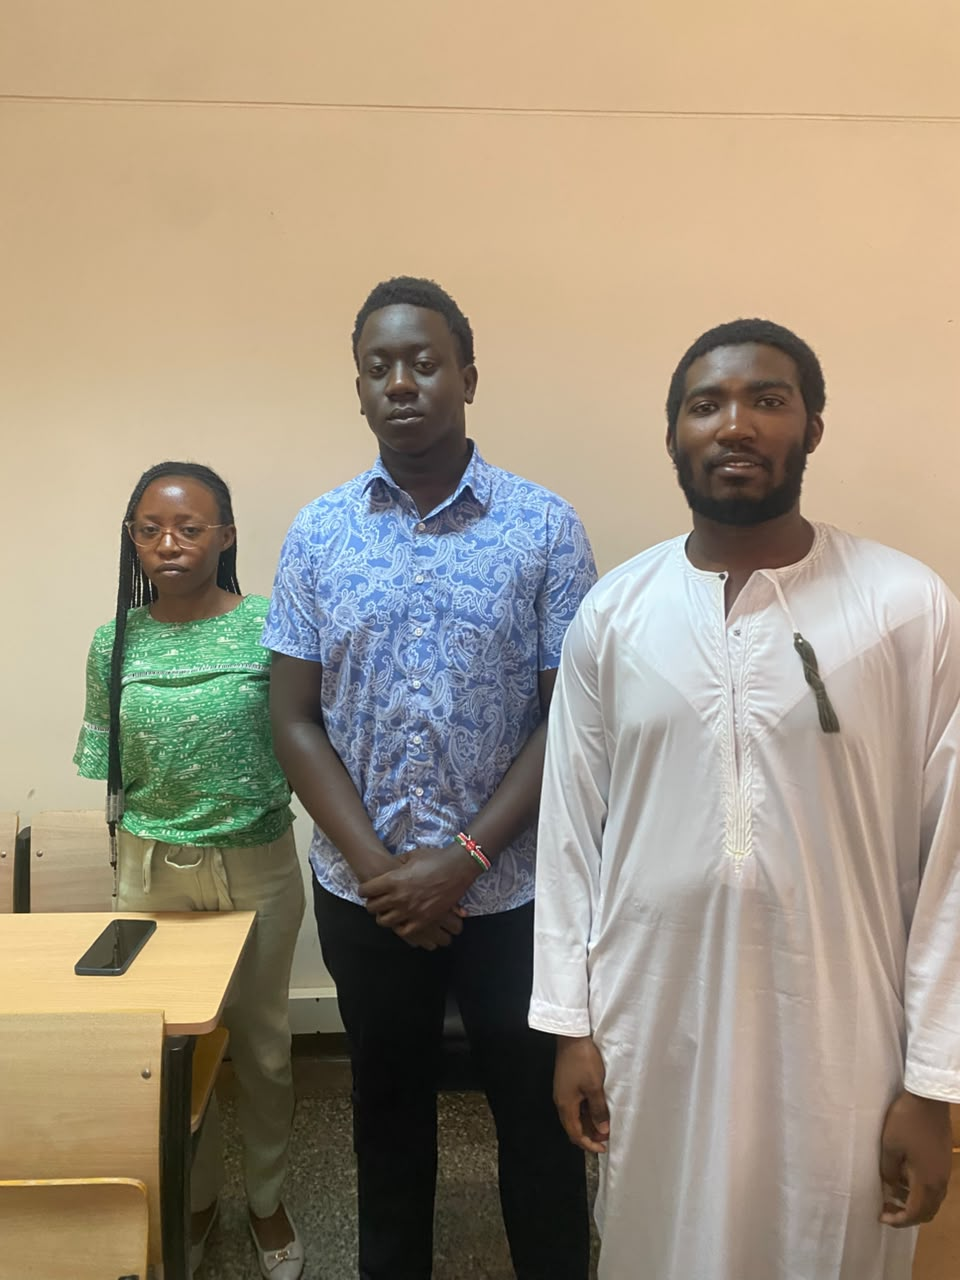

In [ ]:
# Read the uploaded CSV file
df = pd.read_csv("Airplane_Crashes_and_Fatalities_Since_1908.csv")

# Display the first 5 rows
df.head()

,Date,Time,Location,Operator,Flight #,Route,Type,Registration,cn/In,Aboard,Fatalities,Ground,Summary
0,09/17/1908,17:18,"Fort Myer, Virginia",Military - U.S. Army,NaN,Demonstration,Wright Flyer III,NaN,1,2.0,1.0,0.0,"During a demonstration flight, a U.S. Army fly..."
1,07/12/1912,06:30,"AtlantiCity, New Jersey",Military - U.S. Navy,NaN,Test flight,Dirigible,NaN,NaN,5.0,5.0,0.0,First U.S. dirigible Akron exploded just offsh...
2,08/06/1913,NaN,"Victoria, British Columbia, Canada",Private,-,NaN,Curtiss seaplane,NaN,NaN,1.0,1.0,0.0,The first fatal airplane accident in Canada oc...
3,09/09/1913,18:30,Over the North Sea,Military - German Navy,NaN,NaN,Zeppelin L-1 (airship),NaN,NaN,20.0,14.0,0.0,The airship flew into a thunderstorm and encou...
4,10/17/1913,10:30,"Near Johannisthal, Germany",Military - German Navy,NaN,NaN,Zeppelin L-2 (airship),NaN,NaN,30.0,30.0,0.0,Hydrogen gas which was being vented was sucked...


In [ ]:
# Find the number of rows and columns
rows, columns = df.shape

print("Number of rows:", rows)
print("Number of columns:", columns)

Number of rows: 5268
Number of columns: 13


In [ ]:
# Display the last 75 rows
df.tail(75)

,Date,Time,Location,Operator,Flight #,Route,Type,Registration,cn/In,Aboard,Fatalities,Ground,Summary
5193,03/15/2008,08:15,"Nbagu, Nigeria",Trade Wings Aviation Ltd.,NaN,Lagos - Bebi Air Strip,Beechcraft 1900D,5N-JAH,UE-322,3.0,3.0,0.0,The plane crashed while en route. Wreckage was...
5194,04/03/2008,11:00,"Lawa, Suriname",Blue Wing Airlines,NaN,Paramaribo - Lawa,Antonov An-28,PZ-TSO,1AJ007-17,19.0,19.0,0.0,While attempting to land the crew aborted the ...
5195,04/09/2008,23:27,"Bundeena, Australia",Avtex Air Services,NaN,Sydney - Brisbane,Swearingen SA227AC Metroliner III,VH-OZA,AC-600,1.0,1.0,0.0,The pilot of the mail plane reported some mino...
5196,04/11/2008,22:15,"Chrisinau, Moldova",Kata Transportation,NaN,"Chrisinau, Moldova - Antalya, Turkey - Sudan",Antonov An-32,ST-AZL,3009,8.0,8.0,0.0,Just minutes after the take off the plane trie...
5197,04/15/2008,14:30,"Goma, Congo",Hewa Bora Airways,NaN,Goma - Kisangani - Kinshasa,McDonnell Douglas DC-9-51,9Q-CHN,47731,85.0,0.0,47.0,"While attempting to takeoff, the plane failed ..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5263,05/20/2009,06:30,"Near Madiun, Indonesia",Military - Indonesian Air Force,NaN,Jakarta - Maduin,Lockheed C-130 Hercules,A-1325,1982,112.0,98.0,2.0,"While on approach, the military transport cras..."
5264,05/26/2009,NaN,"Near Isiro, DemocratiRepubliCongo",Service Air,NaN,Goma - Isiro,Antonov An-26,9Q-CSA,5005,4.0,4.0,NaN,The cargo plane crashed while on approach to I...
5265,06/01/2009,00:15,"AtlantiOcean, 570 miles northeast of Natal, Br...",Air France,447,Rio de Janeiro - Paris,Airbus A330-203,F-GZCP,660,228.0,228.0,0.0,The Airbus went missing over the AtlantiOcean ...
5266,06/07/2009,08:30,"Near Port Hope Simpson, Newfoundland, Canada",Strait Air,NaN,Lourdes de BlanSablon - Port Hope Simpson,Britten-Norman BN-2A-27 Islander,C-FJJR,424,1.0,1.0,0.0,The air ambulance crashed into hills while att...


In [ ]:
# Check the number of missing values in each column
df.isnull().sum()

,0
Date,0
Time,2219
Location,20
Operator,18
Flight #,4199
Route,1707
Type,27
Registration,335
cn/In,1228
Aboard,22


In [ ]:
# Create a new dataframe from the raw/uncleaned data
fatality_locations = df[['Date', 'Location', 'Aboard', 'Fatalities']].copy()

# Display the new dataframe
fatality_locations.head()

,Date,Location,Aboard,Fatalities
0,09/17/1908,"Fort Myer, Virginia",2.0,1.0
1,07/12/1912,"AtlantiCity, New Jersey",5.0,5.0
2,08/06/1913,"Victoria, British Columbia, Canada",1.0,1.0
3,09/09/1913,Over the North Sea,20.0,14.0
4,10/17/1913,"Near Johannisthal, Germany",30.0,30.0


In [ ]:
# Convert Fatalities to numeric
fatality_locations['Fatalities'] = pd.to_numeric(
    fatality_locations['Fatalities'],
    errors='coerce'
)

# Find the row with the highest number of fatalities
highest_fatality = fatality_locations.loc[
    fatality_locations['Fatalities'].idxmax()
]

print("Date with the highest recorded fatalities:",
      highest_fatality['Date'])

print("Number of fatalities:",
      highest_fatality['Fatalities'])

Date with the highest recorded fatalities: 03/27/1977
Number of fatalities: 583.0


In [ ]:
# Convert Aboard to numeric
fatality_locations['Aboard'] = pd.to_numeric(
    fatality_locations['Aboard'],
    errors='coerce'
)

# Calculate survivors/non-fatalities
fatality_locations['Non_Fatalities'] = (
    fatality_locations['Aboard'] -
    fatality_locations['Fatalities']
)

# Display the comparison
fatality_locations[['Aboard', 'Fatalities', 'Non_Fatalities']].head()

,Aboard,Fatalities,Non_Fatalities
0,2.0,1.0,1.0
1,5.0,5.0,0.0
2,1.0,1.0,0.0
3,20.0,14.0,6.0
4,30.0,30.0,0.0


In [ ]:
# Find crashes where there were no fatalities
no_fatalities = fatality_locations[
    fatality_locations['Fatalities'] == 0
]

print("Number of crashes with no fatalities:",
      len(no_fatalities))

Number of crashes with no fatalities: 58


In [ ]:
# Split Location into Region and State/Country
fatality_locations[['Region', 'State/Country']] = (
    fatality_locations['Location']
    .str.split(',', n=1, expand=True)
)

# Remove unnecessary spaces
fatality_locations['Region'] = (
    fatality_locations['Region'].str.strip()
)

fatality_locations['State/Country'] = (
    fatality_locations['State/Country'].str.strip()
)

# Display the result
fatality_locations.head()

,Date,Location,Aboard,Fatalities,Non_Fatalities,Region,State/Country
0,09/17/1908,"Fort Myer, Virginia",2.0,1.0,1.0,Fort Myer,Virginia
1,07/12/1912,"AtlantiCity, New Jersey",5.0,5.0,0.0,AtlantiCity,New Jersey
2,08/06/1913,"Victoria, British Columbia, Canada",1.0,1.0,0.0,Victoria,"British Columbia, Canada"
3,09/09/1913,Over the North Sea,20.0,14.0,6.0,Over the North Sea,None
4,10/17/1913,"Near Johannisthal, Germany",30.0,30.0,0.0,Near Johannisthal,Germany


In [ ]:
# Sort by fatalities from highest to lowest
top_100_fatalities = fatality_locations.sort_values(
    by='Fatalities',
    ascending=False
).head(100)

# Display the first 100 records
top_100_fatalities

,Date,Location,Aboard,Fatalities,Non_Fatalities,Region,State/Country
2963,03/27/1977,"Tenerife, Canary Islands",644.0,583.0,61.0,Tenerife,Canary Islands
3568,08/12/1985,"Mt. Osutaka, near Ueno Village, Japan",524.0,520.0,4.0,Mt. Osutaka,"near Ueno Village, Japan"
4455,11/12/1996,"Near Charkhidadri, India",349.0,349.0,0.0,Near Charkhidadri,India
2726,03/03/1974,"Near Ermenonville, France",346.0,346.0,0.0,Near Ermenonville,France
3562,06/23/1985,"AtlantiOcean, 110 miles West of Ireland",329.0,329.0,0.0,AtlantiOcean,110 miles West of Ireland
...,...,...,...,...,...,...,...
4852,04/15/2002,"Busan, South Korea",166.0,128.0,38.0,Busan,South Korea
3198,01/21/1980,"Elburz Mtns., near Laskarak, Markazi, Iran",128.0,128.0,0.0,Elburz Mtns.,"near Laskarak, Markazi, Iran"
1701,12/16/1960,"Staten Island / Brooklyn, New York",128.0,128.0,0.0,Staten Island / Brooklyn,New York
5108,07/09/2006,"Irkutsk, Russia",203.0,128.0,75.0,Irkutsk,Russia


In [ ]:
# Calculate total fatalities for each country/state
top_25_locations = (
    fatality_locations
    .groupby('State/Country')['Fatalities']
    .sum()
    .sort_values(ascending=False)
    .head(25)
)

top_25_locations

,Fatalities
State/Country,
Russia,6350.0
Brazil,2938.0
Colombia,2624.0
India,2211.0
France,2017.0
Indonesia,1818.0
California,1691.0
China,1577.0
Peru,1380.0
